In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

### Convert from rtf to csv cos textedit turned them into rtfs

In [61]:
path = Path('../../../digitisedData/elasticoKim2024')
rtfs = list(path.glob('*.rtf'))

In [ ]:
for rtf in rtfs:
    xs, ys = [], []

    flag = False
    with open(rtf, 'r') as f:
        for line in f:
            if flag:
                x, y = line.strip().replace('\\', '').replace('}', '').split(',')
                xs.append(float(x))
                ys.append(float(y))
            if 'x, y' in line:
                flag = True

    pd.DataFrame({'strain':xs, 'stress':ys}).to_csv(rtf.with_suffix('.csv'), index=False)

### Plot them

In [63]:
path = Path('../../../digitisedData/elasticoKim2024')
csvs = list(path.glob('*.csv'))

Text(0, 0.5, 'Engineering stress')

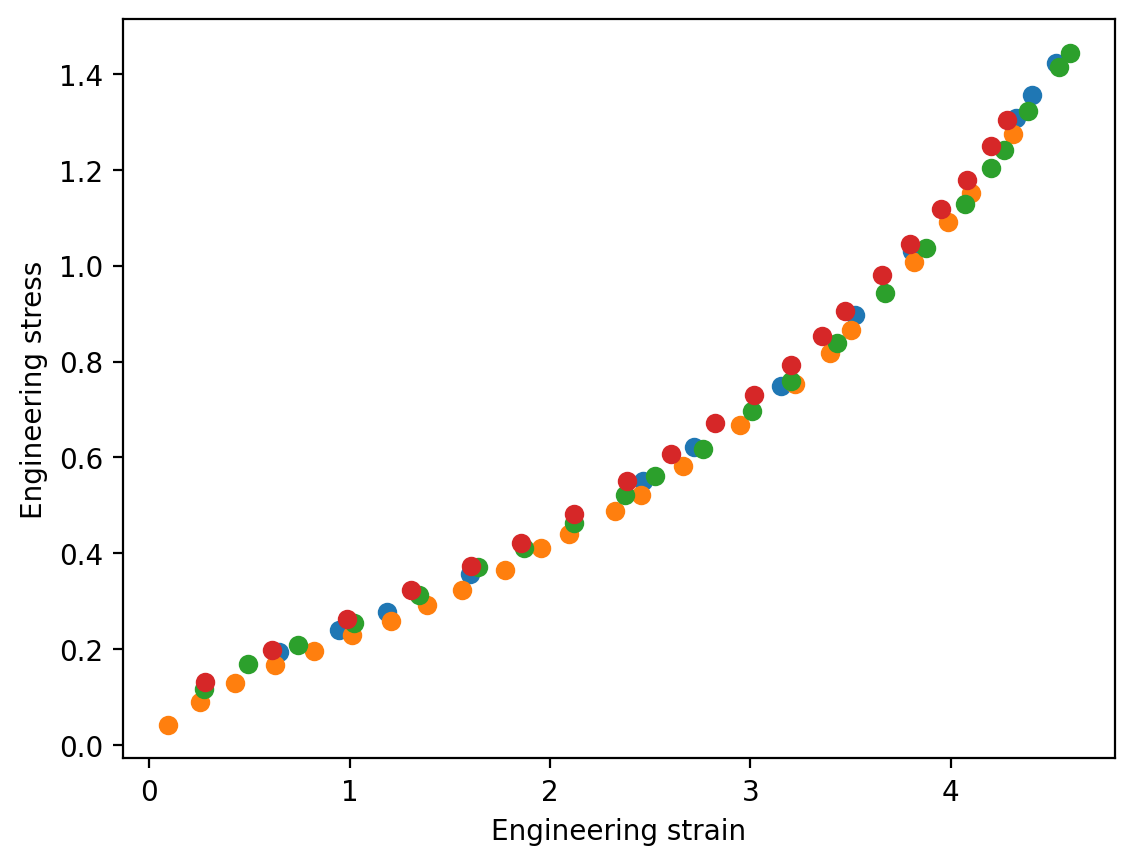

In [72]:
fig, ax = plt.subplots(dpi=200)

for csv in csvs:
    df = pd.read_csv(csv)

    ax.scatter(df['strain'], df['stress'])

ax.set_xlabel('Engineering strain')
ax.set_ylabel('Engineering stress')

#### Probably should have done an equal number of equally spaced points from each of the curves...